# Part II - the ford GoBike dataset analysis
## by Raghad

## Investigation Overview


> Describe the overall goals of your presentation here. Add a summary of key insights at the start of the notebook (i.e., an executive summary). This will help your notebook to stay aligned to the key insights you want to include in your slide deck.

The goal of this analysis is to explore and uncover patterns in the Ford GoBike dataset, which contains information about individual bike rides taken in the San Francisco Bay Area. The focus is on understanding user behavior, trip characteristics, and how these vary across different user types, times, and demographics.



## Dataset Overview and Executive Summary

> Briefly introduce your dataset here. Include a summary of findings that your visualizations will support.

> **Rubric Tip**: The key insights can be in a bulleted or numbered list for ease of review.

The dataset explored in this analysis is the Ford GoBike System Data, which contains detailed records of bike-sharing trips in the San Francisco Bay Area. Each record includes information such as trip duration, start and end times, station names and locations, user type, gender and birth year. Through the exploratory analysis, many key insights were found. Customers, who are typically casual users, tend to take longer and more varied trips compared to Subscribers, who often use the service for short, routine commutes. Usage patterns also differ by day of the week and so on.

In [2]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [3]:
# load in the dataset into a pandas dataframe
df = pd.read_csv('201902-fordgobike-tripdata.csv')


## (Visualization 1)

> Write a comment about your visualization here.  Make sure your visualizations are polished!

> **Rubric Tip**: Provide at least 3 **polished** visualizations to convey key insights. The total number of visualizations shoould be less than 50% of the number of visualizations in the exploratory analysis. Generally 3-5 visualizations suffice.


> **Rubric Tip**: Each visualization in the slideshow is associated with **descriptive comments** that accurately depict their purpose and your observation. 


> **Rubric Tip**: All plots shown are appropriate, meaning the plot type, encodings, and transformations are suitable to the underlying data. 

> **Rubric Tip**: All plots in the slideshow are polished, meaning all plots have a title, labeled x/y axes (with units), x/y ticks, and legends. 

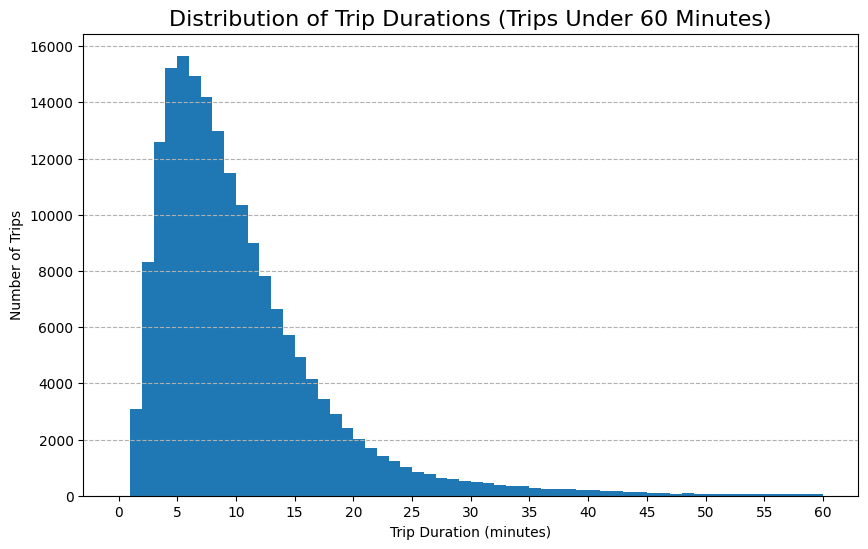

In [6]:
# Convertion
df['duration_min'] = df['duration_sec'] / 60


plt.figure(figsize=(10,6))
bins = np.arange(0, 61, 1)
plt.hist(df[df['duration_min'] <= 60]['duration_min'], bins=bins)
plt.title('Distribution of Trip Durations (Trips Under 60 Minutes)', fontsize=16)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.xticks(np.arange(0, 61, 5))
plt.grid(axis='y', linestyle='--')
plt.show()


This histogram shows the distribution of trip durations for rides that are less than 60 minutes. majority of trips fall within the 5 to 20 minutes. This pattern indicates that most users take relatively short trips. It also highlights a long tail of longer trips, suggesting occasional use or might be outliers. Limiting the view to trips under 60 minutes provides a clearer picture of typical usage without distortion from extremee outliers.

## (Visualization 2)

> You should have at least three visualizations in your presentation, but feel free to add more if you'd like!

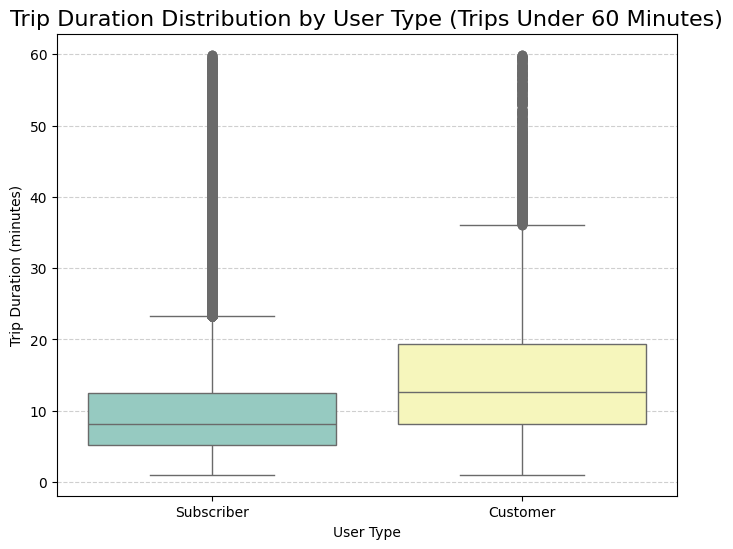

In [7]:
plt.figure(figsize=(8,6))


filtered_df = df[df['duration_min'] <= 60]

sns.boxplot(data=filtered_df, x='user_type', y='duration_min', palette='Set3')
plt.title('Trip Duration Distribution by User Type (Trips Under 60 Minutes)', fontsize=16)
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


This boxplot compares trip durations between subscribers and customers for trips shorter than 60 minutes. It clearly shows that customers tend to take longer rides on average, while Subscribers typically take shorter rides.

## (Visualization 3)

> You should have at least three visualizations in your presentation, but feel free to add more if you'd like!

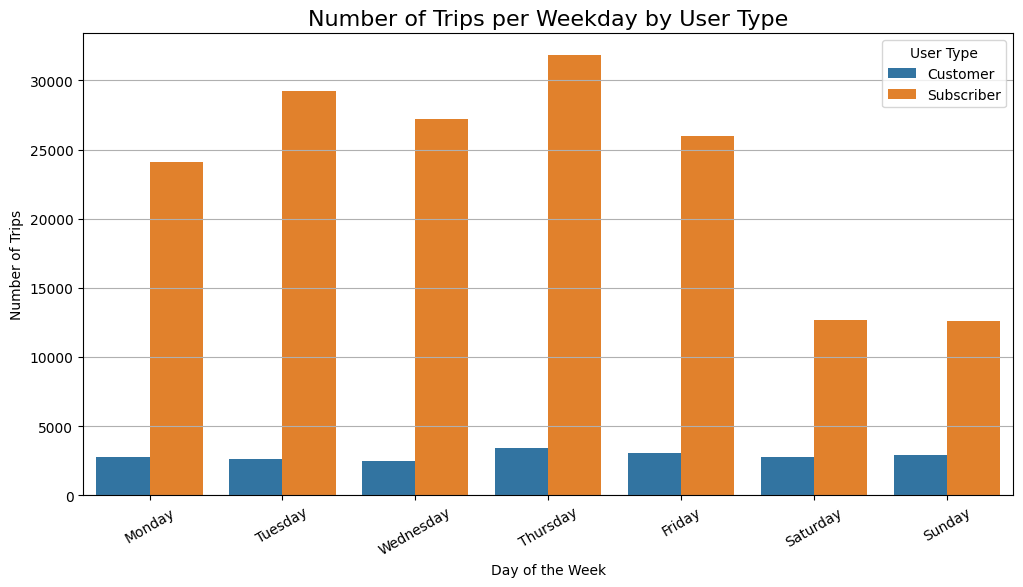

In [9]:

df['start_time'] = pd.to_datetime(df['start_time'])

df['weekday'] = df['start_time'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='weekday', hue='user_type', order=weekday_order)
plt.title('Number of Trips per Weekday by User Type', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.legend(title='User Type')
plt.show()


This bar chart displays the number of trips taken each day of the week, separated by user type. subscribers have a clear dominance on weekdays, especially Monday through Friday. while it is the opposite for customres.

### Submission
If you are using classroom workspace, you can choose from the following two ways of submission:

1. **Submit from the workspace**. Make sure you have removed the example project from the /home/workspace directory. You must submit the following files:
   - Part_I_notebook.ipynb
   - Part_I_notebook.html or pdf
   - Part_II_notebook.ipynb
   - Part_II_notebook.html or pdf


2. **Submit a zip file on the last page of this project lesson**. In this case, open the Jupyter terminal and run the command below to generate a ZIP file. 
```bash
zip -r my_project.zip .
```
The command abobve will ZIP every file present in your /home/workspace directory. Next, you can download the zip to your local, and follow the instructions on the last page of this project lesson.
